In [10]:
#### Read all GEE files anď to Machine Learning Modelling ###

import os
import glob
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
# Folder containing the files
folder = "/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data"

# Find all training_* files
files = glob.glob(os.path.join(folder, "Landsat8_SALSUR_training_*"))

print(f"Found {len(files)} files:")
for f in files:
    print(f)

# Read and combine all files
df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

training_all = pd.concat(df_list, ignore_index=True)

print(training_all.shape)
training_all.head()

Found 10 files:
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_1.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_2.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_3.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_7.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_6.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_4.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_5.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_10.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_8.csv
/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Data/Landsat8_SALSUR_training_9.csv
(1458, 65)


,system:index,AWEI,CID,COMMENT,DATE,DEPTH,DOBOT,DOMID,DOSUR,ENV_LAT,...,TEMPSUR,TIMEENV,TIMESOAK,VESSEL_NO,date,landsat_count,.geo,SECCHI,HOOKSDEPLOYED,HOOKSRETRIEVED
0,000000000000000001e0,-0.499952,23,Water qulaity was taken after set was retrieve...,2013-06-04,15.2,3.7,4.0,6.1,28.7170,...,28.0,0,60.0,88,2013-06-04T00:00:00,7,"{""type"":""Point"",""coordinates"":[-91.15889739990...",NaN,NaN,NaN
1,000000000000000001ec,-0.028915,23,NOAA site: GB037..DO sensor on CTD more than l...,2013-09-09,94.5,NaN,NaN,NaN,28.1765,...,31.1,0,60.0,88,2013-09-09T00:00:00,8,"{""type"":""Point"",""coordinates"":[-91.22480010986...",NaN,NaN,NaN
2,000000000000000001ed,-0.029475,23,NOAA site: GB036..DO sensor more than likely w...,2013-09-09,69.8,NaN,NaN,NaN,28.2712,...,30.9,0,60.0,88,2013-09-09T00:00:00,8,"{""type"":""Point"",""coordinates"":[-90.93650054931...",NaN,NaN,NaN
3,000000000000000001d4,0.003154,23,Water quality was taken with YSI therefore onl...,2013-04-25,14.6,NaN,NaN,3.2,29.1391,...,21.1,0,60.0,97,2013-04-25T00:00:00,4,"{""type"":""Point"",""coordinates"":[-89.64890289306...",NaN,NaN,NaN
4,000000000000000001d5,0.225787,23,Multiple rigs in area. Site directly in mouth...,2013-05-13,27.6,4.3,3.6,5.6,28.9451,...,21.8,0,60.0,97,2013-05-13T00:00:00,5,"{""type"":""Point"",""coordinates"":[-89.31390380859...",NaN,NaN,NaN


In [5]:
keep_cols = [
    'AWEI', 'DATE', 'DEPTH', 'DOSUR',
    'ENV_LAT', 'ENV_LON', 'MNDWI',
    'NDMI', 'NDVI', 'NDWI',
    'SALSUR', 'SID',
    'SR_B1', 'SR_B2', 'SR_B3',
    'SR_B4', 'SR_B5', 'SR_B6',
    'SR_B7',
    'TEMPSUR', 'date', 'SECCHI'
]

training_all = training_all[keep_cols]

In [7]:
print(f"Number of files read: {len(files)}")
print(f"Total rows in training_all: {len(training_all)}")

Number of files read: 10
Total rows in training_all: 1458


### SALSURF ####

In [9]:
# Define predictors and target
features = [
    'AWEI',
    'MNDWI',
    'NDMI',
    'NDVI',
    'NDWI',
    'SR_B1',
    'SR_B2',
    'SR_B3',
    'SR_B4',
    'SR_B5',
    'SR_B6',
    'SR_B7'
]

target = 'SALSUR'

# Remove missing values
model_data = training_all[features + [target]].dropna()

print("Number of samples:", len(model_data))

# Split data (80% training, 20% testing)
X = model_data[features]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest regression model
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_features='sqrt'
)

# Train
rf.fit(X_train, y_train)

# Predict
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Evaluation
print("Training performance:")
print("R²:", r2_score(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

print("\nTesting performance:")
print("R²:", r2_score(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

Number of samples: 1453
Training performance:
R²: 0.913880277905248
RMSE: 2.4178935213853716
MAE: 1.9122413080895082

Testing performance:
R²: 0.3910363394049483
RMSE: 6.710036090100166
MAE: 5.356116838487972


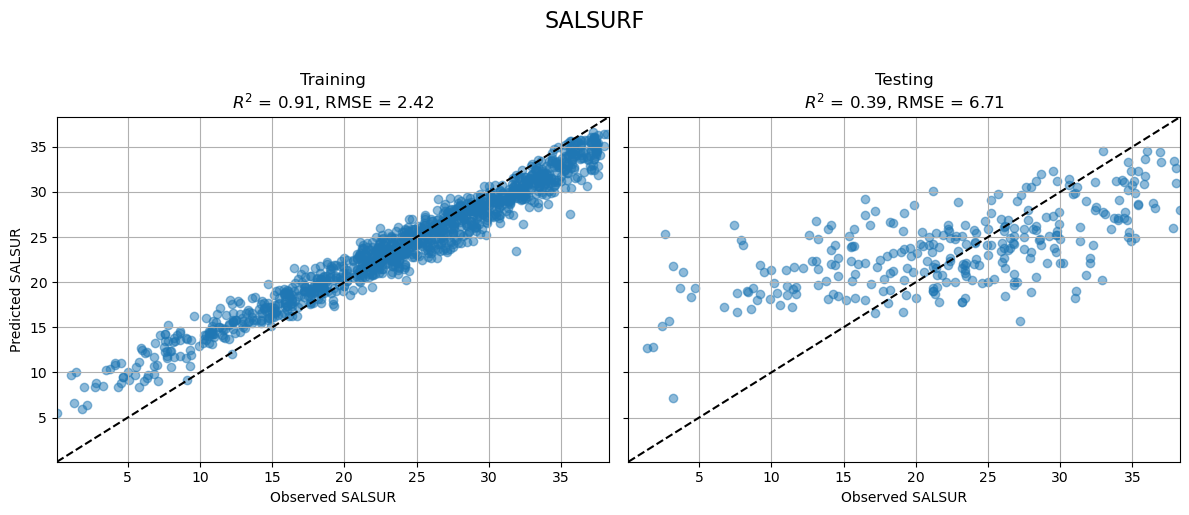

Figure saved to: /Users/bz294/Documents/Collaborations/Liying/Water_Quality/Results/SALSURF_RF_prediction.png


In [13]:
# Calculate metrics
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Axis range
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Main title
fig.suptitle("SALSURF", fontsize=16, y=1.02)

# Training subplot
axes[0].scatter(
    y_train,
    y_train_pred,
    alpha=0.5
)

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    linewidth=1.5
)

axes[0].set_xlabel("Observed SALSUR")
axes[0].set_ylabel("Predicted SALSUR")
axes[0].set_title(
    f"Training\n$R^2$ = {r2_train:.2f}, RMSE = {rmse_train:.2f}"
)

# Testing subplot
axes[1].scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    linewidth=1.5
)

axes[1].set_xlabel("Observed SALSUR")
axes[1].set_title(
    f"Testing\n$R^2$ = {r2_test:.2f}, RMSE = {rmse_test:.2f}"
)

# Formatting
for ax in axes:
    ax.grid(True)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

plt.tight_layout()

# Save figure
out_dir = "/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Results"
os.makedirs(out_dir, exist_ok=True)

out_file = os.path.join(out_dir, "SALSURF_RF_prediction.png")

plt.savefig(
    out_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {out_file}")

### SECCHI ###

In [14]:
target = 'SECCHI'

# Remove missing values
model_data_secchi = training_all[features + [target]].dropna()

print("Number of samples:", len(model_data_secchi))

# Split predictors and target
X = model_data_secchi[features]
y = model_data_secchi[target]

# 80% training, 20% testing
X_train_secchi, X_test_secchi, y_train_secchi, y_test_secchi = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest regression model
rf_secchi = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    max_features='sqrt'
)

# Train model
rf_secchi.fit(
    X_train_secchi,
    y_train_secchi
)

# Predictions
y_train_secchi_pred = rf_secchi.predict(X_train_secchi)
y_test_secchi_pred = rf_secchi.predict(X_test_secchi)

# Evaluation
print("Training performance (SECCHI):")
print("R²:", r2_score(y_train_secchi, y_train_secchi_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train_secchi, y_train_secchi_pred)))
print("MAE:", mean_absolute_error(y_train_secchi, y_train_secchi_pred))

print("\nTesting performance (SECCHI):")
print("R²:", r2_score(y_test_secchi, y_test_secchi_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_secchi, y_test_secchi_pred)))
print("MAE:", mean_absolute_error(y_test_secchi, y_test_secchi_pred))

Number of samples: 1229
Training performance (SECCHI):
R²: 0.9107538992689802
RMSE: 0.659247008757296
MAE: 0.4469373346897251

Testing performance (SECCHI):
R²: 0.1930689000066519
RMSE: 2.1806039038597667
MAE: 1.388932520325203


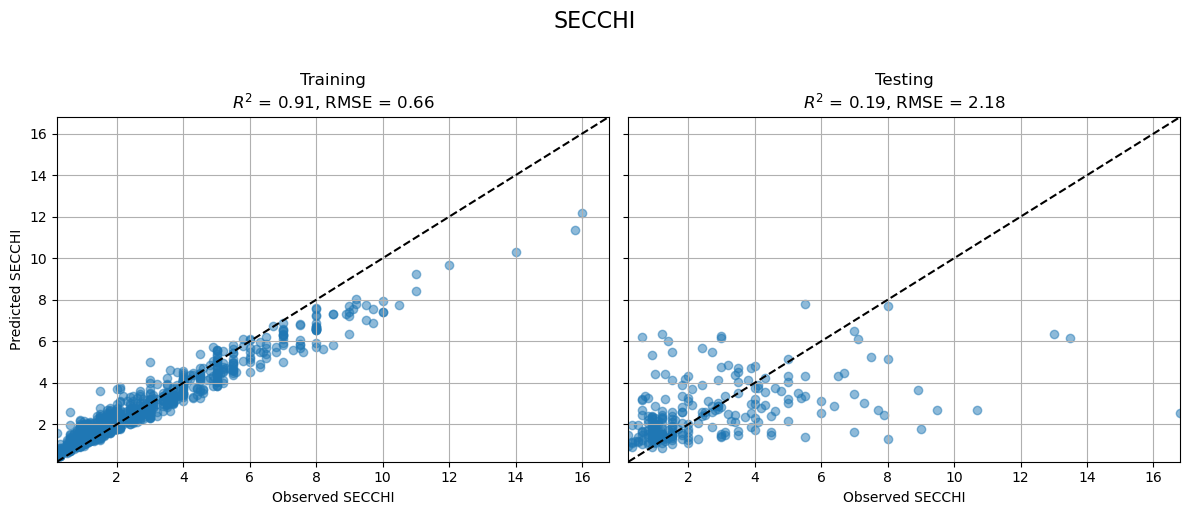

Figure saved to: /Users/bz294/Documents/Collaborations/Liying/Water_Quality/Results/SECCHI_RF_prediction.png


In [15]:
# Calculate metrics
r2_train = r2_score(y_train_secchi, y_train_secchi_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_secchi, y_train_secchi_pred))

r2_test = r2_score(y_test_secchi, y_test_secchi_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_secchi, y_test_secchi_pred))

# Axis range
min_val = min(
    y_train_secchi.min(),
    y_test_secchi.min(),
    y_train_secchi_pred.min(),
    y_test_secchi_pred.min()
)

max_val = max(
    y_train_secchi.max(),
    y_test_secchi.max(),
    y_train_secchi_pred.max(),
    y_test_secchi_pred.max()
)

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharex=True,
    sharey=True
)

# Main title
fig.suptitle("SECCHI", fontsize=16, y=1.02)

# Training subplot
axes[0].scatter(
    y_train_secchi,
    y_train_secchi_pred,
    alpha=0.5
)

axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    linewidth=1.5
)

axes[0].set_xlabel("Observed SECCHI")
axes[0].set_ylabel("Predicted SECCHI")
axes[0].set_title(
    f"Training\n$R^2$ = {r2_train:.2f}, RMSE = {rmse_train:.2f}"
)

# Testing subplot
axes[1].scatter(
    y_test_secchi,
    y_test_secchi_pred,
    alpha=0.5
)

axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    'k--',
    linewidth=1.5
)

axes[1].set_xlabel("Observed SECCHI")
axes[1].set_title(
    f"Testing\n$R^2$ = {r2_test:.2f}, RMSE = {rmse_test:.2f}"
)

# Formatting
for ax in axes:
    ax.grid(True)
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

plt.tight_layout()

# Save figure
out_dir = "/Users/bz294/Documents/Collaborations/Liying/Water_Quality/Results"
os.makedirs(out_dir, exist_ok=True)

out_file = os.path.join(out_dir, "SECCHI_RF_prediction.png")

plt.savefig(
    out_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {out_file}")